In [9]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import fractional_matrix_power

In [10]:
K = 60
n_x = 4
n_y_1 = 2
n_y_2 = 1

A_1 = np.array([[1, 0, 0.2, 0], [0, 1, 0, 0.2], [-0.2, 0, 0.8, 0], [0, 0, 0, 0.8]])
b_1 = np.array([[0], [0], [0.2], [0.2]])
x_initial_1 = np.array([[1], [1], [-15], [3]])

A_2 = np.array([[1, 0, 0.2, 0], [0, 1, 0, 0.2], [-0.1, 0, 0.8, 0], [0, 0, 0, 0.8]])
b_2 = np.array([[0], [0], [0.2], [0.2]])
x_initial_2 = np.array([[-2], [1], [-3], [3]])

P = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])

In [11]:
def f_1(k, x_1_0):
    return np.linalg.matrix_power(A_1, k) @ x_1_0 + np.sum([np.linalg.matrix_power(A_1, n) @ b_1 for n in range(k)], axis=0)

def f_2(k, x_2_0):
    return np.linalg.matrix_power(A_2, k) @ x_2_0 + np.sum([np.linalg.matrix_power(A_2, n) @ b_2 for n in range(k)], axis=0)

def h_1(k, x_1_0):
    return P @ f_1(k, x_1_0)

def h_2(k, x_1_0, x_2_0):
    return np.linalg.norm(P @ f_2(k, x_2_0) - P @ f_1(k, x_1_0))

In [12]:
X_true = np.zeros((n_x + n_x, 1, K))
for k in range(K):
    X_true[:, :, k] = np.vstack((f_1(k, x_initial_1), f_2(k, x_initial_2)))

r_1 = 1e-2
R_1 = r_1**2 * np.eye(n_y_1)
sigma_2 = 1e-1
Y = np.zeros((n_y_1 + n_y_2, 1, K))
for k in range(K):
    Y[:n_y_1, :, k] = h_1(k, x_initial_1) + np.sqrt(R_1) @ np.random.randn(n_y_1, 1)
    Y[n_y_1:n_y_1 + n_y_2, :, k] = h_2(k, x_initial_1, x_initial_2) + sigma_2 * np.random.randn(n_y_2, 1)

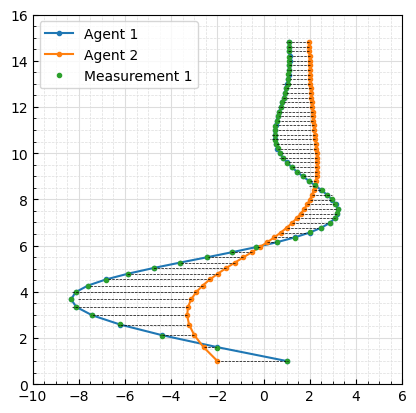

In [13]:
plt.plot(X_true[0, 0, :], X_true[1, 0, :], '.-', label='Agent 1')
plt.plot(X_true[4, 0, :], X_true[5, 0, :], '.-', label='Agent 2')
plt.plot(Y[0, 0, :], Y[1, 0, :], '.', label='Measurement 1')
for k in range(K):
    x1 = X_true[0:2, 0, k]
    x2 = X_true[4:6, 0, k]
    direction = (x2 - x1) / np.linalg.norm(x2 - x1)
    plt.plot([x2[0], x2[0] - Y[2, 0, k] * direction[0]], [x2[1], x2[1] - Y[2, 0, k] * direction[1]], 'k--', linewidth=0.5)
plt.xlim(-10, 6)
plt.ylim(0, 16)
plt.grid(which="major", color="#DDDDDD", linewidth=0.8, zorder=1)
plt.grid(which="minor", color="#DDDDDD", linestyle="dashed", linewidth=0.5, zorder=2)
plt.tick_params(axis='both', which='both', direction='in')
plt.minorticks_on()
plt.grid(True, which="both")
plt.gca().set_aspect("equal")
plt.legend()
plt.show()

In [14]:
def r_function(X_0, Y):
    r = np.zeros(((n_y_1 + n_y_2) * K, 1))
    x_1_0 = X_0[:n_x, :]
    x_2_0 = X_0[n_x:, :]
    for k in range(K):
        x_1_k = f_1(k, x_1_0)
        x_2_k = f_2(k, x_2_0)
        y_1_k = Y[:n_y_1, :, k]
        y_2_k = Y[n_y_1:n_y_1 + n_y_2, :, k]
        r[(n_y_1 + n_y_2) * k:(n_y_1 + n_y_2) * k + n_y_1, :] = fractional_matrix_power(R_1, -1/2) @ (P @ x_1_k - y_1_k)
        r[(n_y_1 + n_y_2) * k + n_y_1:(n_y_1 + n_y_2) * (k + 1), :] = sigma_2**(-1) * (np.linalg.norm(P @ x_2_k - P @ x_1_k) - y_2_k)
    return r

def J_jacobian(X_0):
    J = np.zeros(((n_y_1 + n_y_2) * K, n_x + n_x))
    x_1_0 = X_0[:n_x, :]
    x_2_0 = X_0[n_x:, :]
    for k in range(K):
        x_1_k = f_1(k, x_1_0)
        x_2_k = f_2(k, x_2_0)
        J[(n_y_1 + n_y_2) * k:(n_y_1 + n_y_2) * k + n_y_1, :n_x] = fractional_matrix_power(R_1, -1/2) @ P @ np.linalg.matrix_power(A_1, k)
        J[(n_y_1 + n_y_2) * k + n_y_1:(n_y_1 + n_y_2) * (k + 1), :n_x] = -sigma_2**(-1) * ((P @ x_2_k - P @ x_1_k) / np.linalg.norm(P @ x_2_k - P @ x_1_k)).T @ P @ np.linalg.matrix_power(A_1, k)
        J[(n_y_1 + n_y_2) * k + n_y_1:(n_y_1 + n_y_2) * (k + 1), n_x:] = sigma_2**(-1) * ((P @ x_2_k - P @ x_1_k) / np.linalg.norm(P @ x_2_k - P @ x_1_k)).T @ P @ np.linalg.matrix_power(A_2, k)
    return J

def cost_function(X_0, Y):
    r = r_function(X_0, Y)
    return 1 / 2 * np.linalg.norm(r)**2

In [15]:
def line_search(x_bold_i, delta_x, Y, alpha=0.1, beta=0.7, max_iter=50):
    t = 1
    cost_bold_i = cost_function(x_bold_i, Y)
    for _ in range(max_iter):
        x_pred_i = x_bold_i - t * delta_x
        cost_pred_i = cost_function(x_pred_i, Y)
        if cost_pred_i <= cost_bold_i - alpha * t * (delta_x.T @ delta_x):
            return t
        t *= beta
    return t

In [16]:
# Solution
x_0 = np.array([[1], [0], [0], [0], [0], [1], [0], [0]])
lambda_0 = 1.0

X_0_i = x_0
lambda_i = lambda_0
i = 0
epsilon = 1e-6
max_iter = 100

grad_i_norms = []
costs = []
lambdas_i = []

while i < max_iter:
    r = r_function(X_0_i, Y)
    J = J_jacobian(X_0_i)
    
    # For plotting the results
    grad_i_norm = np.linalg.norm(J.T @ r)
    grad_i_norms.append(grad_i_norm)
    costs.append(cost_function(X_0_i, Y))
    lambdas_i.append(lambda_i)

    if grad_i_norm < epsilon:
        print(f"STOOOOP\nIteration {i}\nGrad_i_norm = {grad_i_norm}\nx_pred_i cost = {cost_function(X_0_pred_i, Y)} | x_bold_i cost = {cost_function(X_0_i, Y)}\nlambda_i = {lambda_i}\n")
        break

    # Solve for the update step
    delta_X_0_i = np.linalg.inv(J.T @ J + lambda_i * np.eye(J.shape[1])) @ J.T @ r

    X_0_pred_i = X_0_i - delta_X_0_i
    
    print(f"Iteration {i}\nGrad_i_norm = {grad_i_norm}\nx_pred_i cost = {cost_function(X_0_pred_i, Y)} | x_bold_i cost = {cost_function(X_0_i, Y)}\nlambda_i = {lambda_i}\n")
    
    if cost_function(X_0_pred_i, Y) < cost_function(X_0_i, Y):
        X_0_i = X_0_pred_i
        lambda_i *= 0.7
    else:
        lambda_i *= 2.0
        
    # alpha = line_search(X_0_i, delta_X_0_i, Y)
    
    # X_0_pred_i = X_0_i - alpha * delta_X_0_i

    i += 1
    
print("Converged to:", X_0_i)
print("Number of iterations:", i)
print("Final cost:", costs[-1])
print("Final grad norm:", grad_i_norms[-1])

Iteration 0
Grad_i_norm = 3162967.4133804934
x_pred_i cost = 18430.291465669194 | x_bold_i cost = 7886206.665670609
lambda_i = 1.0

Iteration 1
Grad_i_norm = 14011.891323182921
x_pred_i cost = 5656.839553627182 | x_bold_i cost = 18430.291465669194
lambda_i = 0.7

Iteration 2
Grad_i_norm = 4762.908594062147
x_pred_i cost = 1734.4600061049018 | x_bold_i cost = 5656.839553627182
lambda_i = 0.48999999999999994

Iteration 3
Grad_i_norm = 2195.732297400025
x_pred_i cost = 325.2108803433676 | x_bold_i cost = 1734.4600061049018
lambda_i = 0.3429999999999999

Iteration 4
Grad_i_norm = 513.6239606314116
x_pred_i cost = 90.43820734162959 | x_bold_i cost = 325.2108803433676
lambda_i = 0.24009999999999992

Iteration 5
Grad_i_norm = 82.66088939159086
x_pred_i cost = 99.1596663198991 | x_bold_i cost = 90.43820734162959
lambda_i = 0.16806999999999994

Iteration 6
Grad_i_norm = 82.66088939159086
x_pred_i cost = 98.79851309225499 | x_bold_i cost = 90.43820734162959
lambda_i = 0.3361399999999999

Iterati

In [17]:
x_1_est = np.zeros((n_x, 1, K))
x_2_est = np.zeros((n_x, 1, K))
for k in range(K):
    x_1_est[:, :, k] = f_1(k, X_0_i[:n_x, :])
    x_2_est[:, :, k] = f_2(k, X_0_i[n_x:, :])

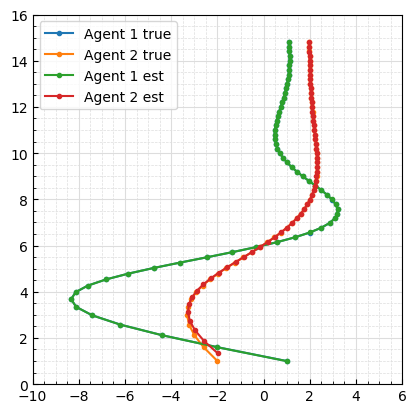

In [18]:
plt.plot(X_true[0, 0, :], X_true[1, 0, :], '.-', label='Agent 1 true')
plt.plot(X_true[4, 0, :], X_true[5, 0, :], '.-', label='Agent 2 true')
plt.plot(x_1_est[0, 0, :], x_1_est[1, 0, :], '.-', label='Agent 1 est')
plt.plot(x_2_est[0, 0, :], x_2_est[1, 0, :], '.-', label='Agent 2 est')
plt.xlim(-10, 6)
plt.ylim(0, 16)
plt.grid(which="major", color="#DDDDDD", linewidth=0.8, zorder=1)
plt.grid(which="minor", color="#DDDDDD", linestyle="dashed", linewidth=0.5, zorder=2)
plt.tick_params(axis='both', which='both', direction='in')
plt.minorticks_on()
plt.grid(True, which="both")
plt.gca().set_aspect("equal")
plt.legend()
plt.show()